In [1]:
import csv

csv_path = "perm_results.csv"
null_accuracies = []

with open(csv_path, newline="") as f:
    reader = csv.reader(f)
    next(reader, None)  # skip header if present; remove this line if no header
    for row in reader:
        if len(row) >= 5 and row[4] != "":
            null_accuracies.append(float(row[4]))  # fifth column (0-based index 4)


In [2]:
len(null_accuracies)

6435

In [3]:
null_accuracies[0]

0.798667

In [4]:
from scipy.io import savemat

savemat("null_accuracies.mat", {"null_accuracies": null_accuracies})

In [5]:
true_accuracy = 0.8013333333333335

In [6]:
import pandas as pd
import numpy as np

df = pd.read_csv("perm_results.csv")

# identify columns
def col(df, name, fallback_idx):
    # use named column if present, else fallback to positional
    return df[name] if name in df.columns else df.iloc[:, fallback_idx]

acc = pd.to_numeric(col(df, "true_accuracy", 4), errors="coerce").to_numpy()
perm = pd.to_numeric(col(df, "perm_idx", 0), errors="coerce").to_numpy()

# match with float tolerance
mask = np.isfinite(acc) & np.isclose(acc, true_accuracy, rtol=1e-9, atol=1e-12)
rows = np.flatnonzero(mask)

if rows.size:
    print("Row indices (0-based):", rows.tolist())
    print("perm_idx values:", perm[rows].astype(int).tolist())
    first_perm_idx = int(perm[rows[0]])
    print("First perm_idx:", first_perm_idx)
else:
    i = int(np.nanargmin(np.abs(acc - true_accuracy)))
    print("Exact match not found.")
    print(f"Closest -> row {i}, perm_idx {int(perm[i])}, accuracy {acc[i]}")


Exact match not found.
Closest -> row 330, perm_idx 331, accuracy 0.801333


In [7]:
true_accuracy = null_accuracies[i]
print(true_accuracy)

0.801333


In [8]:
count = 0

for acc in null_accuracies:
    if true_accuracy <= acc:
        count += 1

count / len(null_accuracies)

0.012276612276612277

In [9]:
count = 0

for acc in null_accuracies:
    if true_accuracy >= acc:
        count += 1

count / len(null_accuracies)

0.9881895881895882

Analytic per-k stats for p = (# >= true_accuracy)/k. \

    If augment_observed=True (default), every k-sample is *augmented* \
    with the observed permutation (true_accuracy) exactly once. \
      - Without replacement: draw k-1 from the remaining n-1 items (Hypergeometric). \
      - With  replacement : draw k-1 with probability q (Binomial). \
    This guarantees min p-value >= 1/k (or higher if not enough failures remain).

In [10]:
# Calculate theoretical minimum p-value
theoretical_min = 1.0 / len(null_accuracies)
print(f"Total number of permutations: {len(null_accuracies)}")
print(f"Theoretical minimum p-value: {theoretical_min}")
print(f"Theoretical minimum p-value (scientific): {theoretical_min:.6e}")

Total number of permutations: 6435
Theoretical minimum p-value: 0.0001554001554001554
Theoretical minimum p-value (scientific): 1.554002e-04


In [11]:
import numpy as np

def _count_successes(null_accuracies, true_accuracy):
    """
    Return total count n and successes s where success := (arr >= true_accuracy).
    Assumes true_accuracy is one element of arr (observed permutation).
    """
    arr = np.asarray(null_accuracies)
    if arr.ndim != 1:
        raise ValueError("null_accuracies must be a 1D array.")
    n = arr.size
    s = int(np.sum(arr >= true_accuracy))
    return n, s

def _stats_dict(ks, p_min, p_max, p_mean, p_median, p_std):
    ks = np.asarray(ks, dtype=int)
    return {
        "k": ks,
        # keep n=1 so 'SE' band equals SD; prefer band='sd' when plotting.
        "n": np.ones_like(ks, dtype=int),
        "p_min":    np.asarray(p_min,    dtype=float),
        "p_max":    np.asarray(p_max,    dtype=float),
        "p_mean":   np.asarray(p_mean,   dtype=float),
        "p_median": np.asarray(p_median, dtype=float),
        "p_std":    np.asarray(p_std,    dtype=float),
    }

def pval_stats_by_k_analytic(null_accuracies, true_accuracy, ks=None, replacement="without", augment_observed=True):
    n, s = _count_successes(null_accuracies, true_accuracy)
    if n == 0:
        raise ValueError("null_accuracies must be non-empty.")

    if ks is None:
        ks = np.arange(1, n + 1, dtype=int) if replacement == "without" else np.arange(1, max(n, 1) + 1, dtype=int)
    else:
        ks = np.asarray(ks, dtype=int)
        if (ks <= 0).any():
            raise ValueError("All k values must be >= 1.")

    # enforce feasibility for without-replacement: we draw (k-1) from (n-1) after augmentation
    if replacement == "without" and (ks > n).any():
        raise ValueError("For sampling without replacement, each k must be <= n (with augmentation).")

    k = ks.astype(float)
    q = s / n  # overall success fraction

    if not augment_observed:
        # original (unaugmented) formulas
        if replacement == "without":
            mean = np.full_like(k, q, dtype=float)
            if n > 1:
                var = (q * (1 - q) / k) * ((n - k) / (n - 1.0))
            else:
                var = np.zeros_like(k)
            std = np.sqrt(np.clip(var, 0.0, None))
            p_min = np.maximum(0.0, (k - (n - s)) / k)
            p_max = np.minimum(1.0, np.minimum(k, s) / k)
            med = np.clip(np.round(k * q) / k, p_min, p_max)
        elif replacement == "with":
            mean = np.full_like(k, q, dtype=float)
            var = (q * (1 - q)) / k
            std = np.sqrt(np.clip(var, 0.0, None))
            if 0 < s < n:
                p_min = np.zeros_like(k); p_max = np.ones_like(k)
            elif s == 0:
                p_min = np.zeros_like(k); p_max = np.zeros_like(k)
            else:
                p_min = np.ones_like(k);  p_max = np.ones_like(k)
            med = np.clip(np.round(k * q) / k, np.minimum(p_min, p_max), np.maximum(p_min, p_max))
        else:
            raise ValueError("replacement must be 'without' or 'with'.")
        return _stats_dict(ks, p_min, p_max, mean, med, std)

    # CORRECTION!!!
    if replacement == "without":
        # draw X ~ Hypergeom(N=n-1, K=s-1, draws=k-1); p = (1 + X)/k
        if n == 1:
            # only the observed permutation exists
            # only feasible k is 1; p == 1
            mean   = np.ones_like(k)
            std    = np.zeros_like(k)
            p_min  = np.ones_like(k)
            p_max  = np.ones_like(k)
            med    = np.ones_like(k)
        else:
            N = n - 1.0
            K = max(s - 1, 0)
            pi = K / N if N > 0 else 1.0  # success prob in the remainder
            draws = k - 1.0

            # mean/variance of X, then scale to p = (1 + X)/k
            EX = draws * pi
            # hypergeometric variance; guard for tiny N (n<=2) → deterministic
            VarX = np.where(
                n > 2,
                draws * pi * (1 - pi) * ((N - draws) / (N - 1.0)),
                0.0
            )
            mean = (1.0 + EX) / k
            std  = np.sqrt(np.clip(VarX, 0.0, None)) / k

            # bounds:
            # min extra successes = max(0, (k-1) - (#failures remaining))
            failures_rem = n - s
            min_extra = np.maximum(0.0, (k - 1.0) - failures_rem)
            max_extra = np.minimum(k - 1.0, s - 1.0)
            p_min = (1.0 + min_extra) / k
            p_max = (1.0 + max_extra) / k

            # approx median: nearest integer to mean of (1 + X), scaled by k
            med_int = np.round(1.0 + EX)
            med = med_int / k
            med = np.clip(med, p_min, p_max)

    elif replacement == "with":
        # draw X ~ Binomial(k-1, q); p = (1 + X)/k
        draws = k - 1.0
        EX = draws * q
        VarX = draws * q * (1.0 - q)
        mean = (1.0 + EX) / k
        std  = np.sqrt(np.clip(VarX, 0.0, None)) / k

        # !!!bounds with augmentation!!!
        # always at least 1 success (the observed); max is 1 + (k-1) if q>0 else 1
        p_min = np.full_like(k, 1.0) / k
        p_max = np.where(s > 1, np.ones_like(k), np.full_like(k, 1.0) / k)

        med_int = np.round(1.0 + EX)
        med = med_int / k
        med = np.clip(med, p_min, p_max)

    else:
        raise ValueError("replacement must be 'without' or 'with'.")

    return _stats_dict(ks, p_min, p_max, mean, med, std)

def pval_stats_both_analytic(null_accuracies, true_accuracy, ks=None, augment_observed=True):
    stats_wout = pval_stats_by_k_analytic(null_accuracies, true_accuracy, ks=ks,
                                          replacement="without", augment_observed=augment_observed)
    stats_with = pval_stats_by_k_analytic(null_accuracies, true_accuracy, ks=ks,
                                          replacement="with", augment_observed=augment_observed)
    return stats_wout, stats_with


In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, FuncFormatter

# return first present key as np.array; else default/fallback.
def _arr(stats, keys, fallback_len=None, default=None):
    for k in keys:
        if k in stats and stats[k] is not None:
            return np.asarray(stats[k])
    if fallback_len is not None:
        return np.full(fallback_len, default)
    return None

def _k_from_stats(stats):
    if "k" in stats and stats["k"] is not None:
        return np.asarray(stats["k"])
    L = len(stats.get("p_mean", []))
    return np.arange(1, L + 1)

def _band_values(std, n, band="se"):
    if std is None:
        return None
    if band == "se" and n is not None:
        return std / np.sqrt(n)
    return std  # 'sd' or missing n

def plot_pval_lines(
    stats,
    title,
    band="se",               # 'se' (±1 standard error) or 'sd' (±1 std)
    y_zoom=(0.0, 0.045),     # zoom! the p-value axis
    x_tick_step=500,         # tick every 500 k-steps (ignored if log_scale=True)
    save_path=None,
    dpi=300,
    show_theoretical_min=False,  # whether to plot theoretical minimum (1/k)
    log_scale=False          # whether to use log scale for x-axis
):
    k        = _k_from_stats(stats)
    p_mean   = _arr(stats, ["p_mean", "mean"])
    p_median = _arr(stats, ["p_median", "median"], fallback_len=len(k), default=np.nan)
    p_std    = _arr(stats, ["p_std", "std"],       fallback_len=len(k), default=np.nan)
    n_per_k  = _arr(stats, ["n_per_k", "n"])

    # support multiple possible min/max key names
    p_min    = _arr(stats, ["p_min", "min", "p_lo", "lo"])
    p_max    = _arr(stats, ["p_max", "max", "p_hi", "hi"])

    band_vals = _band_values(p_std, n_per_k, band=band)
    y_lo = p_mean - band_vals if band_vals is not None else None
    y_hi = p_mean + band_vals if band_vals is not None else None

    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    
    # Set larger, bold fonts
    plt.rcParams['font.size'] = 14
    plt.rcParams['font.weight'] = 'bold'
    plt.rcParams['axes.labelweight'] = 'bold'
    plt.rcParams['axes.titleweight'] = 'bold'

    # lines (no markers)
    ax.plot(k, p_mean,   linewidth=2.0, label="mean")

    # theoretical minimum: 1/k for each k
    if show_theoretical_min:
        theoretical_min_values = 1.0 / k
        ax.plot(k, theoretical_min_values, linewidth=1.5, linestyle="--", color="red", label="theoretical min (1/k)")

    # shaded band around the mean
    if y_lo is not None and y_hi is not None:
        ax.fill_between(k, y_lo, y_hi, alpha=0.18, label=f"±1 {band.upper()}")

    # axes formatting
    ax.set_xlabel("k (combination size)", fontsize=14, fontweight='bold')
    ax.set_ylabel("p-value", fontsize=14, fontweight='bold')
    if y_zoom is not None:
        ax.set_ylim(*y_zoom)

    ax.set_xlim(k.min(), k.max())
    
    if log_scale:
        ax.set_xscale('log')
        ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'$10^{{{int(np.log10(x))}}}$' if x >= 1 and np.log10(x) == int(np.log10(x)) else ''))
    else:
        from matplotlib.ticker import MultipleLocator
        ax.xaxis.set_major_locator(MultipleLocator(x_tick_step))
        ax.xaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{int(v):d}"))

    ax.grid(True, linestyle=":", linewidth=0.8, alpha=0.6)
    ax.tick_params(axis='both', which='major', labelsize=12)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')
    ax.legend(loc="best", frameon=False, fontsize=12, prop={'weight': 'bold'})

    if save_path:
        os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        plt.close(fig)
    else:
        plt.show()
    return fig

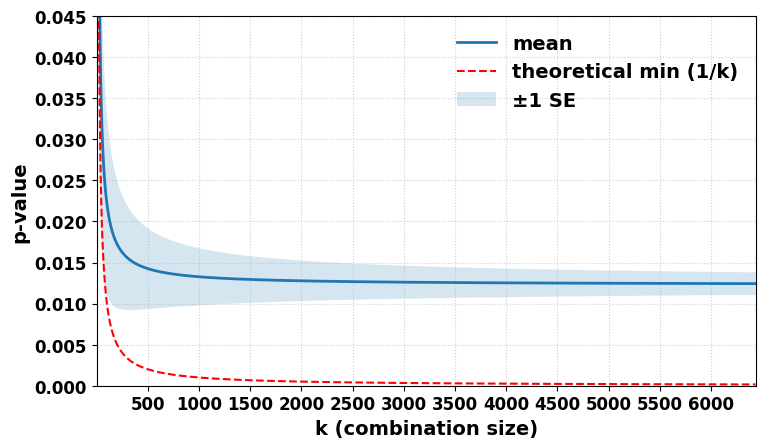

In [13]:
stats_wout, stats_with = pval_stats_both_analytic(null_accuracies, true_accuracy)

plot_pval_lines(
    stats_wout,
    title="Without replacement",
    band="se",
    y_zoom=(0.0, 0.045),
    x_tick_step=500,
    save_path="./pvals_without_lines.png",
    show_theoretical_min=True
)

plot_pval_lines(
    stats_with,
    title="With replacement",
    band="se",
    y_zoom=(0.0, 0.045),
    x_tick_step=500,
    save_path="./pvals_with_lines.png",
    show_theoretical_min=True
)

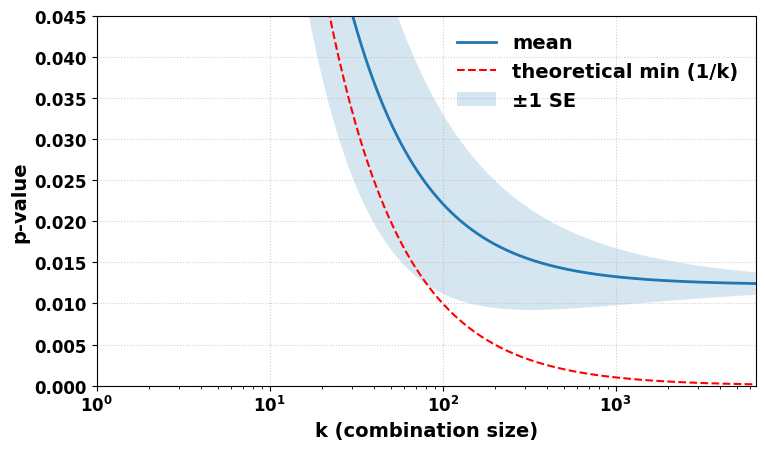

In [14]:
# Plot with log scale x-axis
stats_wout, stats_with = pval_stats_both_analytic(null_accuracies, true_accuracy)

plot_pval_lines(
    stats_wout,
    title="Without replacement (log scale)",
    band="se",
    y_zoom=(0.0, 0.045),
    x_tick_step=500,
    save_path="./pvals_without_lines_logscale.png",
    show_theoretical_min=True,
    log_scale=True
)

plot_pval_lines(
    stats_with,
    title="With replacement (log scale)",
    band="se",
    y_zoom=(0.0, 0.045),
    x_tick_step=500,
    save_path="./pvals_with_lines_logscale.png",
    show_theoretical_min=True,
    log_scale=True
)

In [15]:
def plot_pval_lines_percentage(
    stats,
    title,
    band="se",
    y_zoom=(0.0, 0.045),
    x_tick_step=10,  # tick every 10% by default
    save_path=None,
    dpi=300,
    show_theoretical_min=False
):
    k        = _k_from_stats(stats)
    p_mean   = _arr(stats, ["p_mean", "mean"])
    p_median = _arr(stats, ["p_median", "median"], fallback_len=len(k), default=np.nan)
    p_std    = _arr(stats, ["p_std", "std"],       fallback_len=len(k), default=np.nan)
    n_per_k  = _arr(stats, ["n_per_k", "n"])

    # support multiple possible min/max key names
    p_min    = _arr(stats, ["p_min", "min", "p_lo", "lo"])
    p_max    = _arr(stats, ["p_max", "max", "p_hi", "hi"])

    band_vals = _band_values(p_std, n_per_k, band=band)
    y_lo = p_mean - band_vals if band_vals is not None else None
    y_hi = p_mean + band_vals if band_vals is not None else None

    # Convert k to percentage of max k
    k_max = k.max()
    k_percent = (k / k_max) * 100

    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    
    # Set larger, bold fonts
    plt.rcParams['font.size'] = 14
    plt.rcParams['font.weight'] = 'bold'
    plt.rcParams['axes.labelweight'] = 'bold'
    plt.rcParams['axes.titleweight'] = 'bold'

    # lines (no markers)
    ax.plot(k_percent, p_mean, linewidth=2.0, label="mean")

    # theoretical minimum: 1/k for each k
    if show_theoretical_min:
        theoretical_min_values = 1.0 / k
        ax.plot(k_percent, theoretical_min_values, linewidth=1.5, linestyle="--", color="red", label="theoretical min (1/k)")

    # shaded band around the mean
    if y_lo is not None and y_hi is not None:
        ax.fill_between(k_percent, y_lo, y_hi, alpha=0.18, label=f"±1 {band.upper()}")

    # axes formatting
    ax.set_xlabel(f"k (% of max permutations, n={int(k_max)})", fontsize=14, fontweight='bold')
    ax.set_ylabel("p-value", fontsize=14, fontweight='bold')
    if y_zoom is not None:
        ax.set_ylim(*y_zoom)

    ax.set_xlim(0, 100)
    
    from matplotlib.ticker import MultipleLocator
    ax.xaxis.set_major_locator(MultipleLocator(x_tick_step))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{int(v)}%"))

    ax.grid(True, linestyle=":", linewidth=0.8, alpha=0.6)
    ax.tick_params(axis='both', which='major', labelsize=12)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')
    ax.legend(loc="best", frameon=False, fontsize=12, prop={'weight': 'bold'})

    if save_path:
        os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        plt.close(fig)
    else:
        plt.show()
    return fig

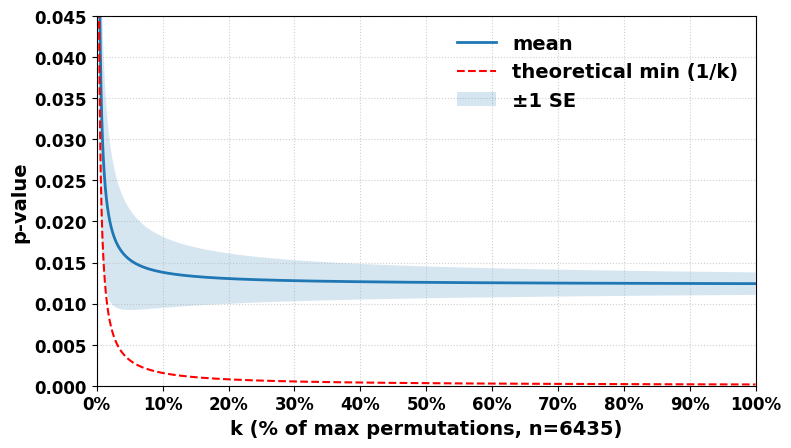

In [16]:
# Plot with percentage x-axis
stats_wout, stats_with = pval_stats_both_analytic(null_accuracies, true_accuracy)

plot_pval_lines_percentage(
    stats_wout,
    title="Without replacement (% of max permutations)",
    band="se",
    y_zoom=(0.0, 0.045),
    x_tick_step=10,
    save_path="./pvals_without_lines_percentage.png",
    show_theoretical_min=True
)

plot_pval_lines_percentage(
    stats_with,
    title="With replacement (% of max permutations)",
    band="se",
    y_zoom=(0.0, 0.045),
    x_tick_step=10,
    save_path="./pvals_with_lines_percentage.png",
    show_theoretical_min=True
)

Write the min and mean in separate csv files

In [17]:
import os
import csv
import numpy as np

def write_min_per_k_csv(stats, csv_path, include_header=True):
    k = np.asarray(stats.get("k"))
    if k is None or k.size == 0:
        raise ValueError("stats must include a non-empty 'k' array.")

    for key in ("p_min", "min", "p_lo", "lo"):
        if key in stats and stats[key] is not None:
            p_min = np.asarray(stats[key], dtype=float)
            break
    else:
        raise ValueError("stats must include one of: 'p_min', 'min', 'p_lo', 'lo'.")

    if p_min.shape[0] != k.shape[0]:
        raise ValueError(f"Length mismatch: len(k)={k.shape[0]} vs len(p_min)={p_min.shape[0]}.")

    order = np.argsort(k)
    k_sorted = k[order].astype(int)
    pmin_sorted = p_min[order].astype(float)

    os.makedirs(os.path.dirname(csv_path) or ".", exist_ok=True)

    with open(csv_path, "w", newline="") as f:
        w = csv.writer(f)
        if include_header:
            w.writerow(["k", "p_min"])
        for ki, pi in zip(k_sorted, pmin_sorted):
            w.writerow([int(ki), float(pi)])


In [18]:
stats_wout, stats_with = pval_stats_both_analytic(null_accuracies, true_accuracy, augment_observed=True)
write_min_per_k_csv(stats_wout, "pmin_without.csv")
write_min_per_k_csv(stats_with,  "pmin_with.csv")

In [19]:
import os
import csv
import numpy as np

def write_mean_per_k_csv(stats, csv_path, include_header=True):
    k = np.asarray(stats.get("k"))
    if k is None or k.size == 0:
        raise ValueError("stats must include a non-empty 'k' array.")

    for key in ("p_mean", "mean"):
        if key in stats and stats[key] is not None:
            p_mean = np.asarray(stats[key], dtype=float)
            break
    else:
        raise ValueError("stats must include one of: 'p_mean', 'mean'.")

    if p_mean.shape[0] != k.shape[0]:
        raise ValueError(f"Length mismatch: len(k)={k.shape[0]} vs len(p_mean)={p_mean.shape[0]}.")

    order = np.argsort(k)
    k_sorted = k[order].astype(int)
    pmean_sorted = p_mean[order].astype(float)

    os.makedirs(os.path.dirname(csv_path) or ".", exist_ok=True)
    with open(csv_path, "w", newline="") as f:
        w = csv.writer(f)
        if include_header:
            w.writerow(["k", "p_mean"])
        for ki, pi in zip(k_sorted, pmean_sorted):
            w.writerow([int(ki), float(pi)])


In [20]:
stats_wout, stats_with = pval_stats_both_analytic(null_accuracies, true_accuracy, augment_observed=True)
write_mean_per_k_csv(stats_wout, "pmean_without.csv")
write_mean_per_k_csv(stats_with,  "pmean_with.csv")